In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from scipy import signal
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from data_preparation.data_processor import DataProcessor

# Exploratory Data Analysis of Daily Waste Quantities

In [25]:
waste_data = pd.read_csv("../synthetic_waste_data.csv")
waste_data

,date,arrival_time,company,truck_id,waste_type,quantity_tons,quality_score,moisture_content,contamination_level,heating_value_MJ_per_kg
0,2022-01-01,2022-01-01 06:27:00,RegionalWaste Management,Reg3,Municipal,11.486050,7.929559,37.493209,2.070441,7.263229
1,2022-01-01,2022-01-01 06:32:00,RegionalWaste Management,Reg1,Industrial,19.855091,6.868888,18.746604,3.131112,11.807504
2,2022-01-01,2022-01-01 09:58:00,GreenWaste Solutions,Gre2,Organic,3.835948,6.364174,74.986417,3.635826,2.539645
3,2022-01-01,2022-01-01 10:06:00,IndustrialProcess Ltd,Ind1,Industrial,41.565434,8.821311,18.746604,1.178689,12.570800
4,2022-01-01,2022-01-01 10:14:00,GreenWaste Solutions,Gre1,Municipal,4.895075,6.149050,37.493209,3.850950,6.849568
...,...,...,...,...,...,...,...,...,...,...
17313,2024-12-31,2024-12-31 11:40:00,BuildRight Construction,Bui1,Construction,11.027408,5.704726,20.470406,4.295274,5.970507
17314,2024-12-31,2024-12-31 13:17:00,MunicipalWaste Co,Mun3,Municipal,16.620243,7.470465,34.117343,2.529535,7.385865
17315,2024-12-31,2024-12-31 13:34:00,IndustrialProcess Ltd,Ind3,Industrial,20.554325,8.548314,17.058671,1.451686,12.633587
17316,2024-12-31,2024-12-31 14:45:00,CommercialServices Inc,Com1,Commercial,16.317348,7.322251,22.744895,2.677749,9.278920


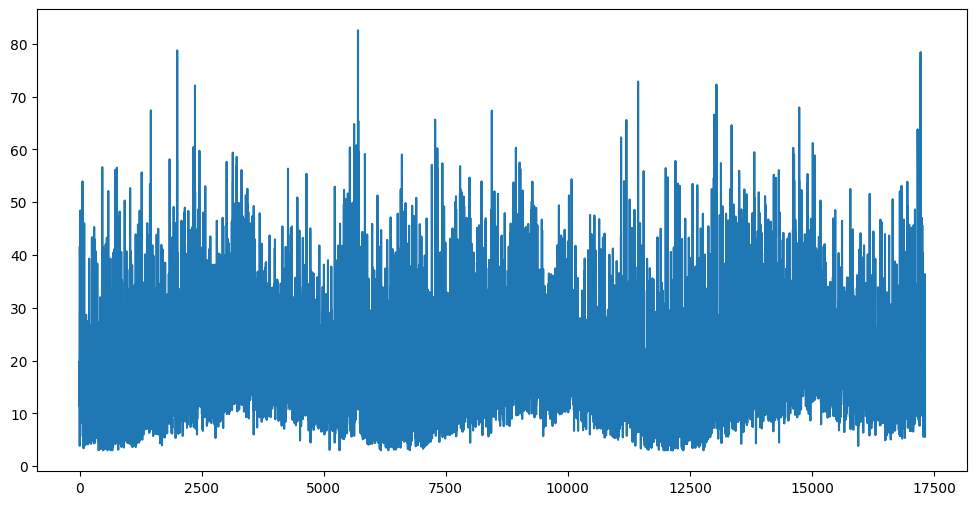

In [26]:
plt.figure(figsize=(12,6))
plt.plot(waste_data["quantity_tons"])
plt.show()

Data is very noise, probably because there are many arrivals per day -> Aggregate the arriving waste day-wise

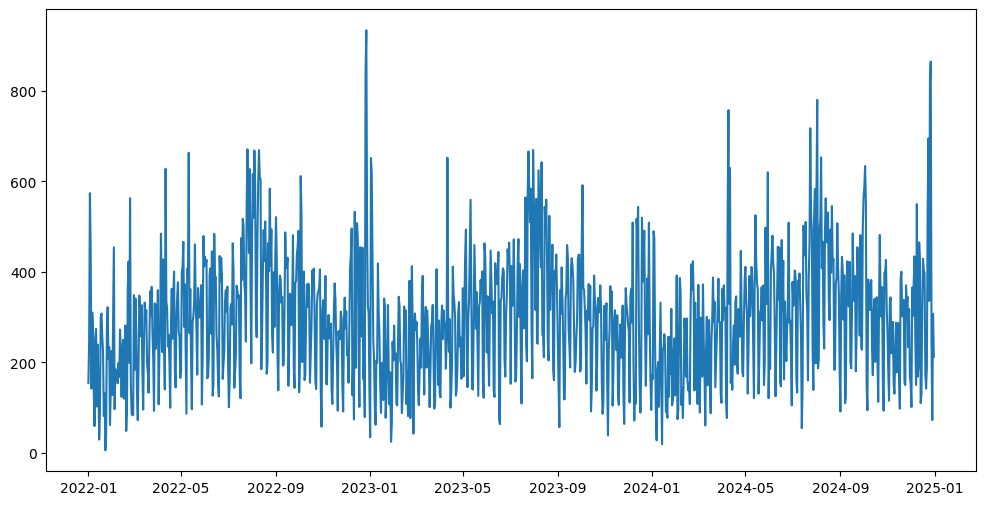

In [27]:
waste_data['date'] = pd.to_datetime(waste_data['date'])

aggregated_waste_data = waste_data.groupby(waste_data['date'].dt.date)['quantity_tons'].sum()

plt.figure(figsize=(12,6))
plt.plot(aggregated_waste_data)
plt.show()

There is a noticeable  yearly pattern in the data. Still, it is a rather noisy time series -> Moving average for better inspection.

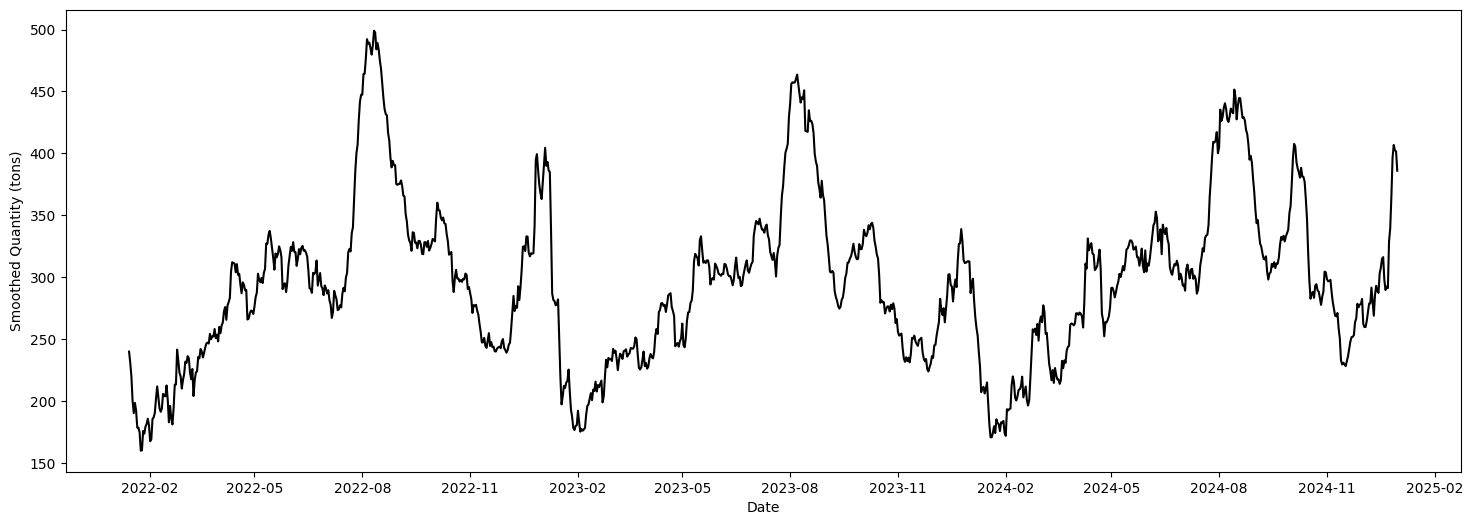

In [28]:
window_size = 14  
agg_waste_df = pd.DataFrame(aggregated_waste_data)
agg_waste_df['smoothed'] = agg_waste_df['quantity_tons'].rolling(window=window_size).mean()

start_date = '2022-01-01'  
freq = 'D' 

agg_waste_df = agg_waste_df.copy()
agg_waste_df['date'] = pd.date_range(start=start_date, periods=len(agg_waste_df), freq=freq)
agg_waste_df = agg_waste_df.set_index('date')


plt.figure(figsize=(18, 6))
plt.plot(agg_waste_df.index, agg_waste_df['smoothed'], color="black")
plt.xlabel('Date')
plt.ylabel('Smoothed Quantity (tons)')
#plt.title('Smoothed Waste Quantity (tons)')
plt.grid(False)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))    
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format as Year-Month

plt.show()

Some dates are particularly eye catching:

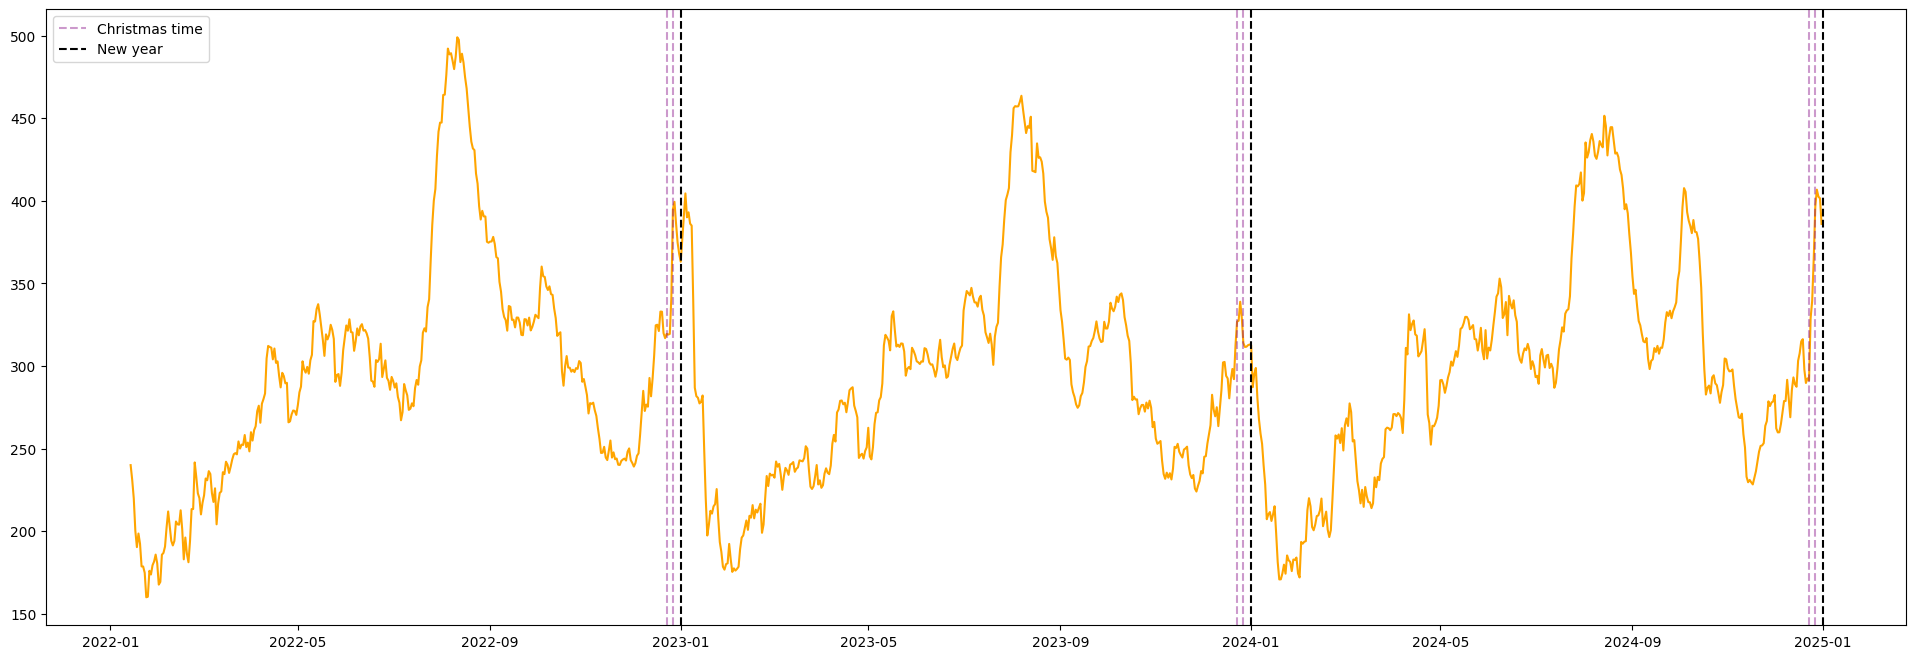

In [29]:
holidays = {
    'Christmas time': {
        'dates': ['2022-12-23', '2022-12-27', '2023-12-23', '2023-12-27', '2024-12-23', '2024-12-27'],
        'color': 'purple',
        'linestyle': '--',
        'alpha': 0.4
    },
    'New year': {
        'dates': ['2023-01-01', '2024-01-01', '2025-01-01'],
        'color': 'black',
        'linestyle': '--',
        'alpha': 1.0
    }
}
plt.figure(figsize=(24,8))
plt.plot(agg_waste_df['smoothed'], color = "orange")

for holiday_name, holiday_info in holidays.items():
    # Plot first date with label
    plt.axvline(
        x= pd.to_datetime(holiday_info['dates'][0]), 
        color=holiday_info['color'], 
        linestyle=holiday_info['linestyle'], 
        label=holiday_name,
        alpha=holiday_info['alpha']
    )
    
    # Plot remaining dates without label
    for date in holiday_info['dates'][1:]:
        plt.axvline(
            x=pd.to_datetime(date), 
            color=holiday_info['color'], 
            linestyle=holiday_info['linestyle'],
            alpha=holiday_info['alpha']
        )
plt.legend()
plt.show()

Implication: Special holidays should be considered in the forecasting model, e.g. via a binary variable.
Also there are peaks towards the end of summer, so considering the season might be important as well

## Difference between Weekdays and Weekends

In [30]:
agg_waste_df = agg_waste_df.reset_index()
agg_waste_df["date"] = pd.to_datetime(agg_waste_df["date"])

# Create a new column that identifies weekday vs weekend
agg_waste_df['is_weekend'] = agg_waste_df['date'].dt.dayofweek >= 5  # 5=Saturday, 6=Sunday

# Create a day type column 
agg_waste_df['day_type'] = agg_waste_df['is_weekend'].apply(lambda x: 'Weekend' if x else 'Weekday')


weekday_vs_weekend = agg_waste_df.groupby('day_type')['quantity_tons'].sum().reset_index()
total_tons = weekday_vs_weekend['quantity_tons'].sum()
weekday_vs_weekend['percentage'] = (weekday_vs_weekend['quantity_tons'] / total_tons * 100).round(2)


print(weekday_vs_weekend)

  day_type  quantity_tons  percentage
0  Weekday  274704.392868       84.68
1  Weekend   49693.266869       15.32


Implication: Type of day should be considered in the forecasting model, e.g. via a binary variable

## Distribution of Waste Types

In [31]:

waste_data = pd.read_csv("../synthetic_waste_data.csv")

fetcher = DataProcessor(waste_data)

unique_waste = fetcher.waste_data['waste_type'].unique()
waste_dfs = {}


for waste in unique_waste:
    waste_dfs[waste] = fetcher.agg_quantity(waste_type=waste, by_waste_type= True)


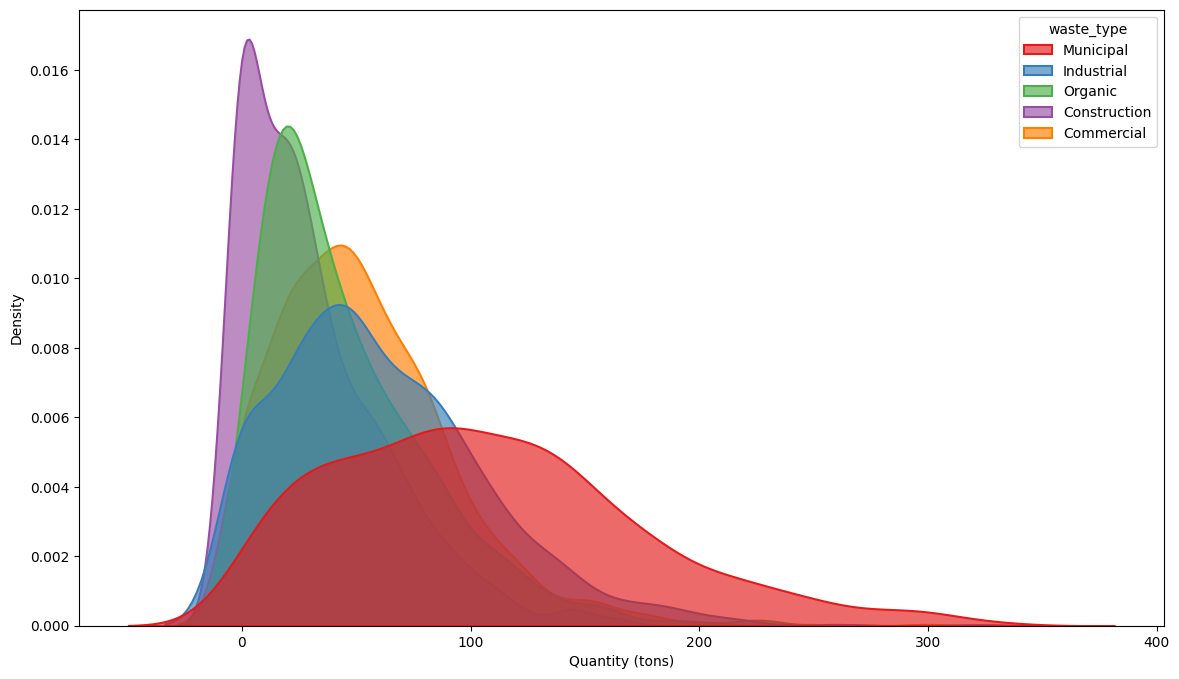

In [32]:
# Create combined dataframe 
all_waste_data = []

for waste in unique_waste:
    temp_df = waste_dfs[waste][['quantity_tons']].copy()
    temp_df['waste_type'] = waste
    all_waste_data.append(temp_df)

# Concatenate into one dataframe
all_waste_data = pd.concat(all_waste_data, ignore_index=True)


plt.figure(figsize=(14, 8))
waste_type_palette = sns.color_palette(["#7fc97f", "#beaed4", "#fdc086", "#ffff65", "#386cb0"])
waste_type_palette2 = sns.color_palette(["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"])

sns.kdeplot(
    data=all_waste_data,
    x='quantity_tons',
    hue='waste_type',      # separate by waste type
    fill=True,             # fill under the curves
    common_norm=False,     
    palette=waste_type_palette2,        
    alpha=0.65,             # Transparency
    linewidth=1.5            # Line thickness
)

#plt.title('Distribution of Daily Waste Quantity (tons) by Waste Type')
plt.xlabel('Quantity (tons)')
plt.ylabel('Density')
plt.grid(False)
plt.show()

Waste types exhibit unique distributions -> Waste types should be modeled individually

## Plots of Waste Quantities by Waste Type

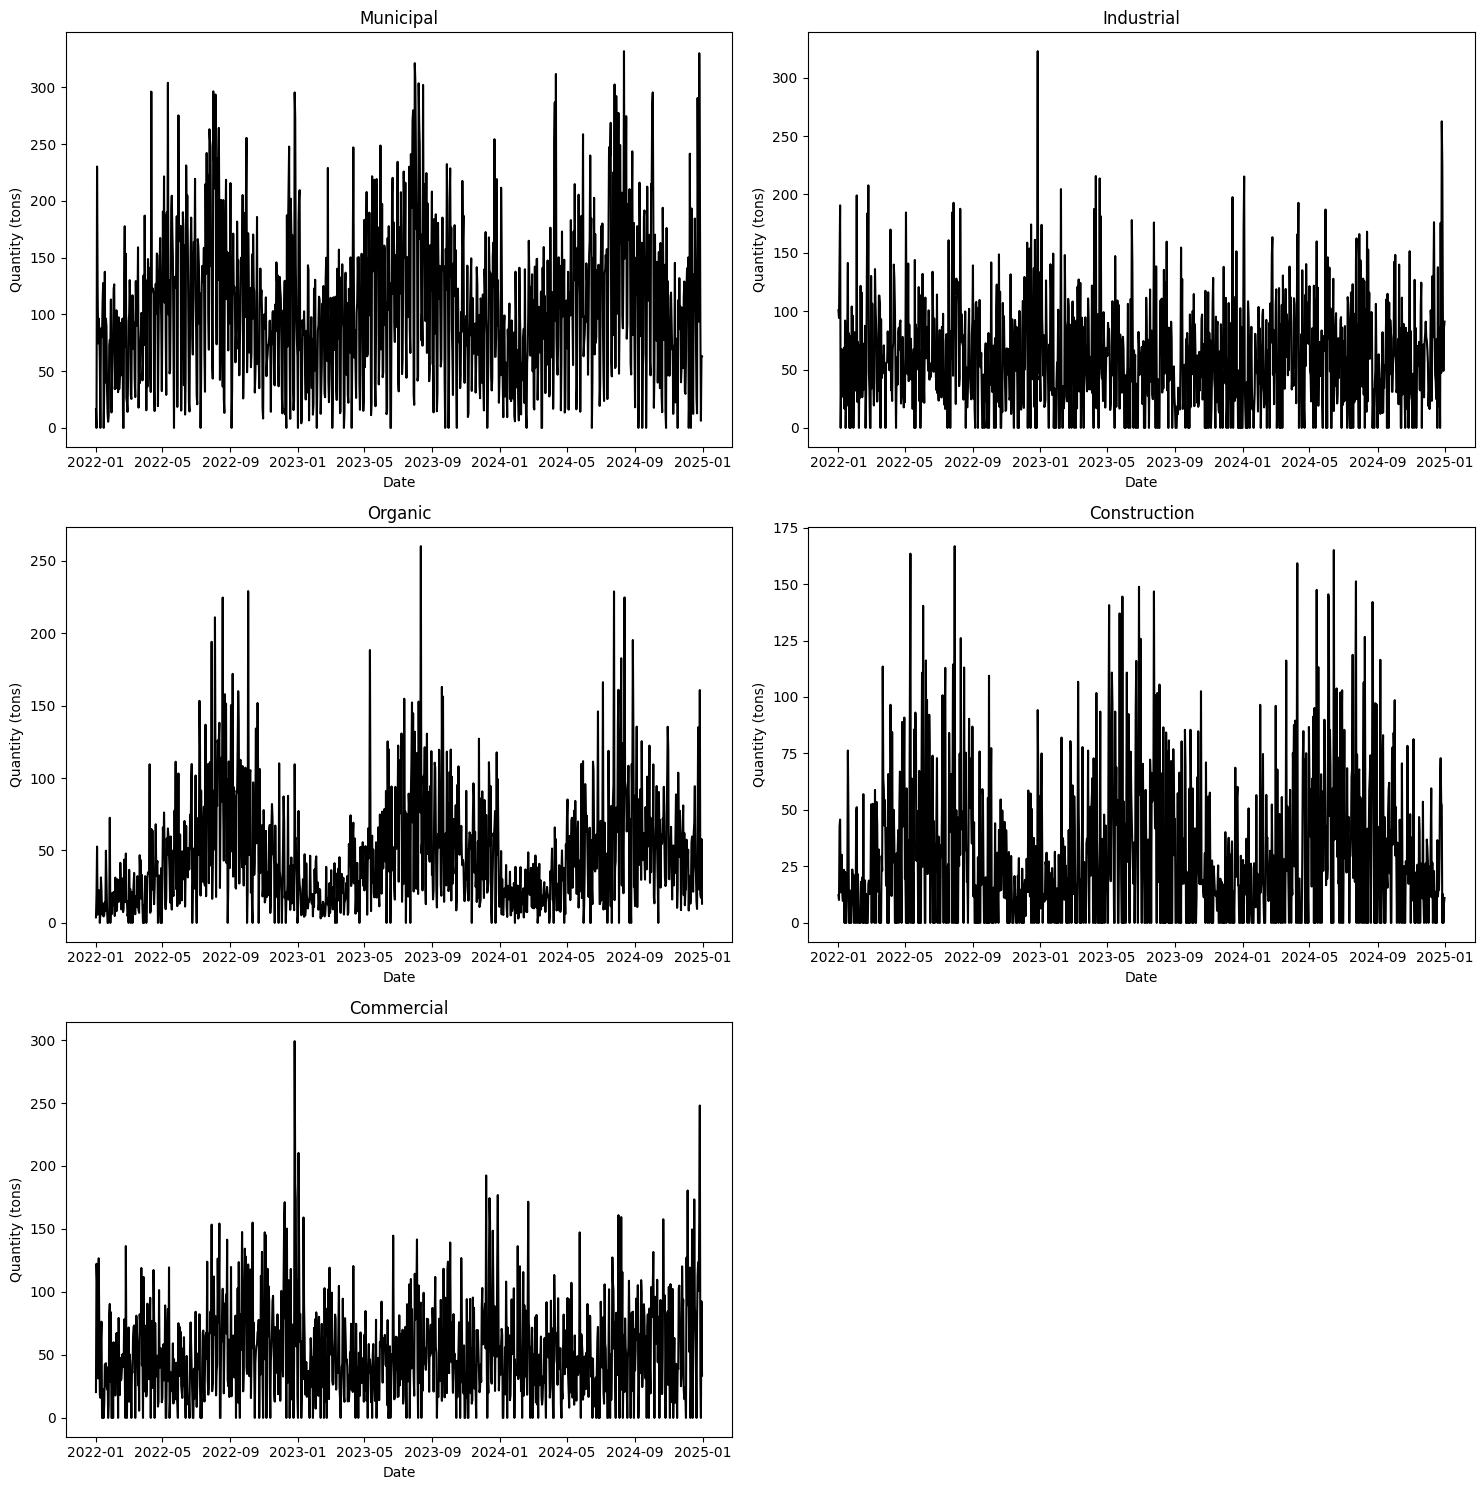

In [33]:
# Set up the plot grid size
n_wastes = len(waste_dfs)
n_cols = 2  
n_rows = (n_wastes + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows), sharex=False, sharey=False)
axes = axes.flatten()  

for idx, (waste_type, df) in enumerate(waste_dfs.items()):
    ax = axes[idx]

    # Plot the quantity_tons over time
    ax.plot(df['quantity_tons'], color='black')

    ax.set_title(waste_type)
    ax.set_xlabel('Date')
    ax.set_ylabel('Quantity (tons)')
    ax.grid(False)

# Hide any empty subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

No trend is evident -> makes data suitable for XGBoost

## Autocorrelation

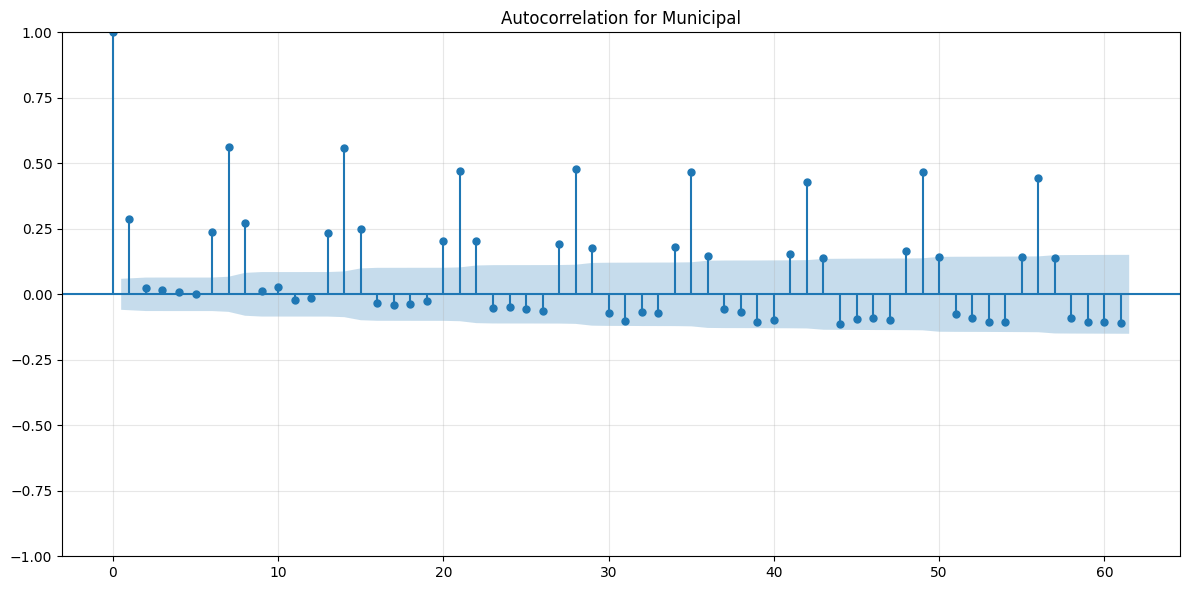

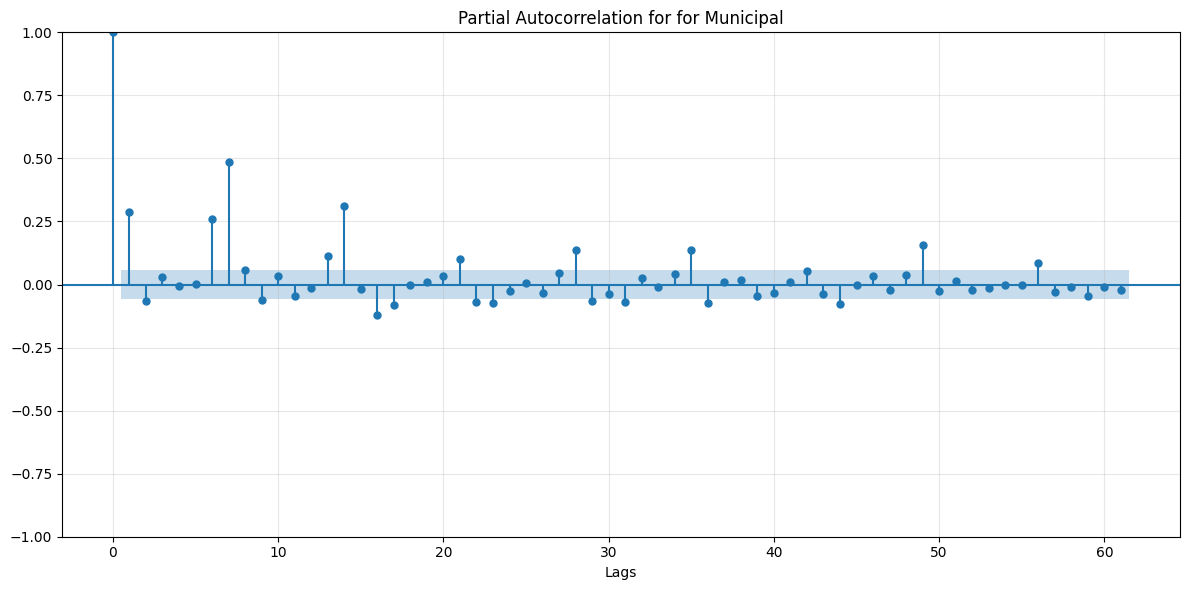

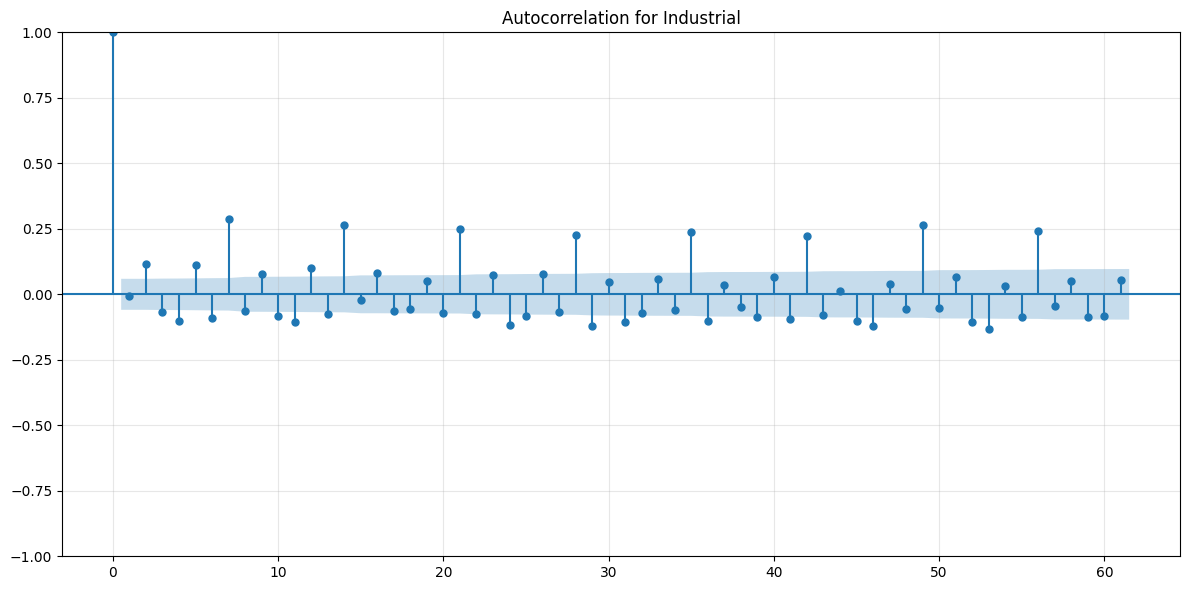

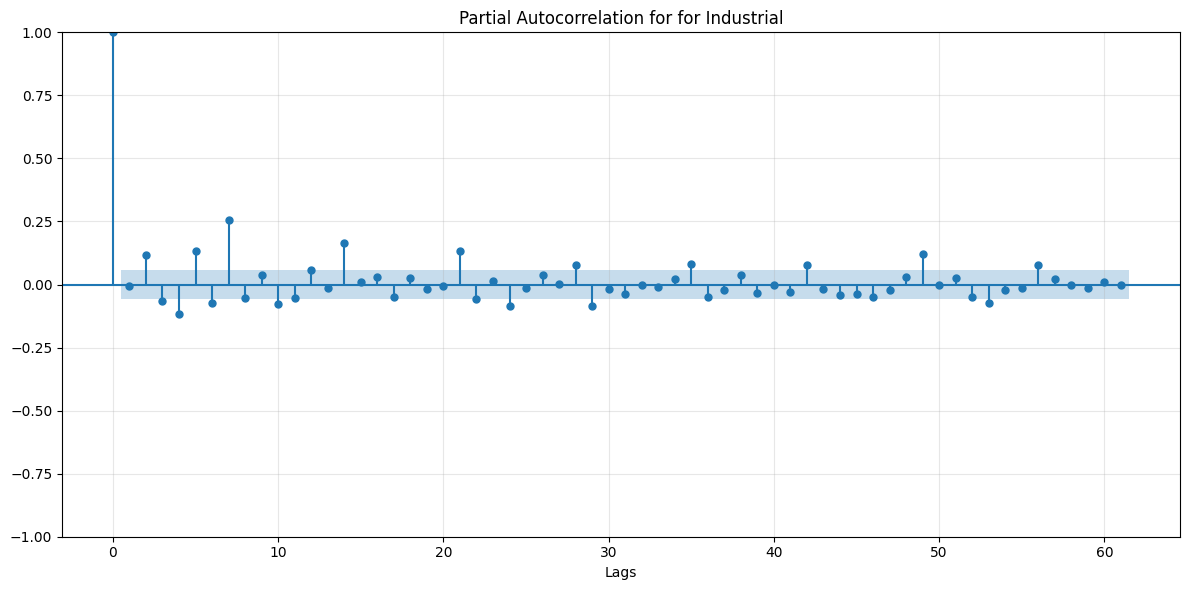

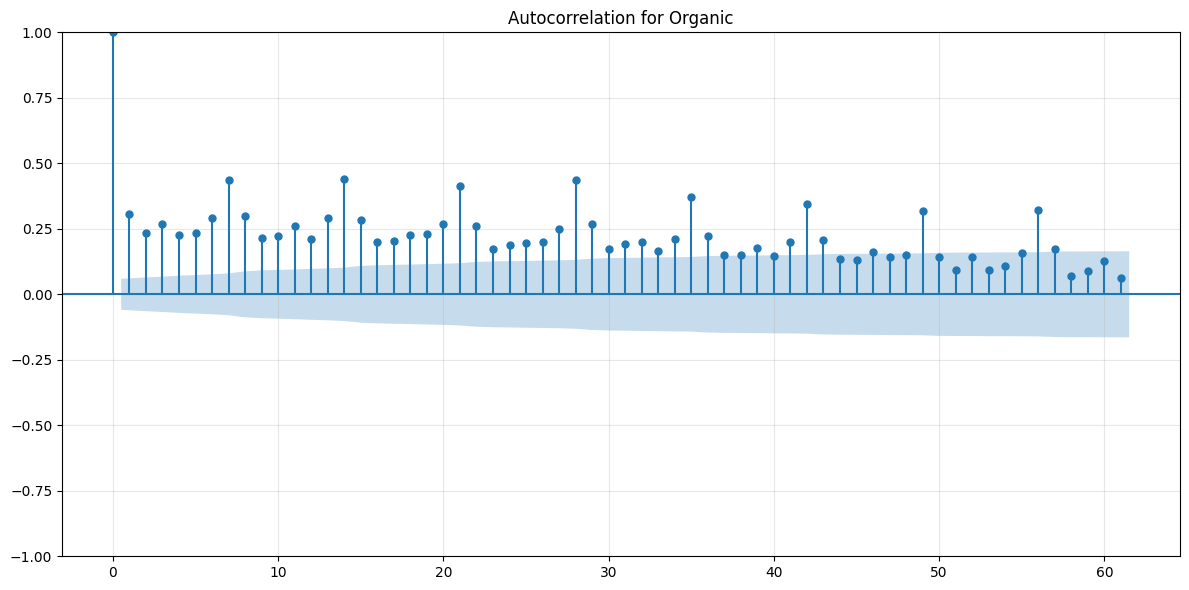

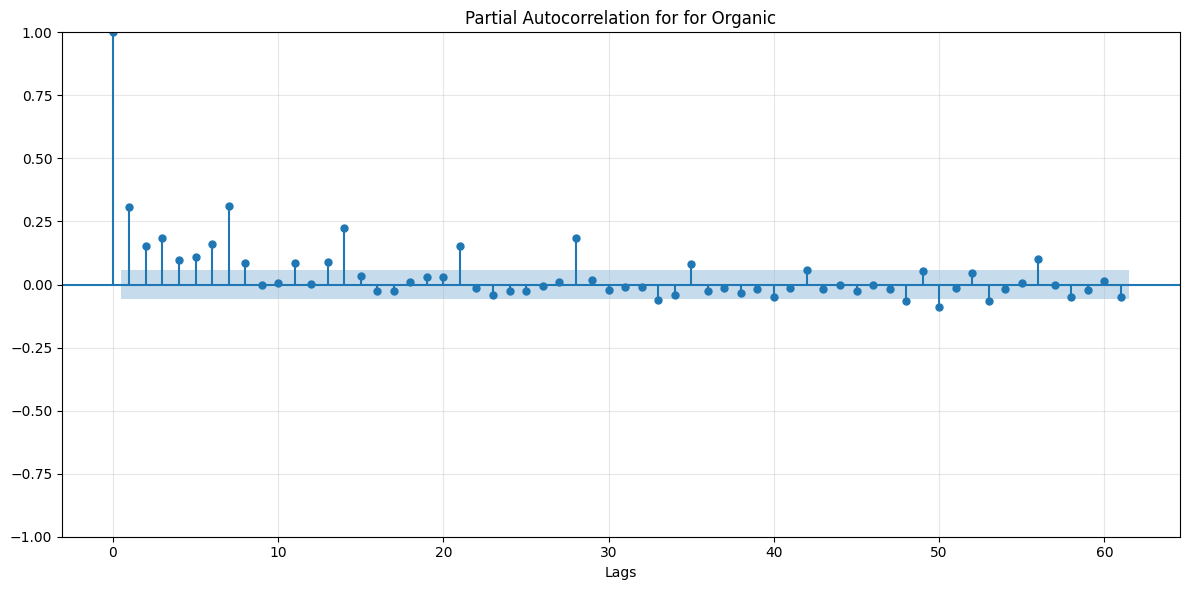

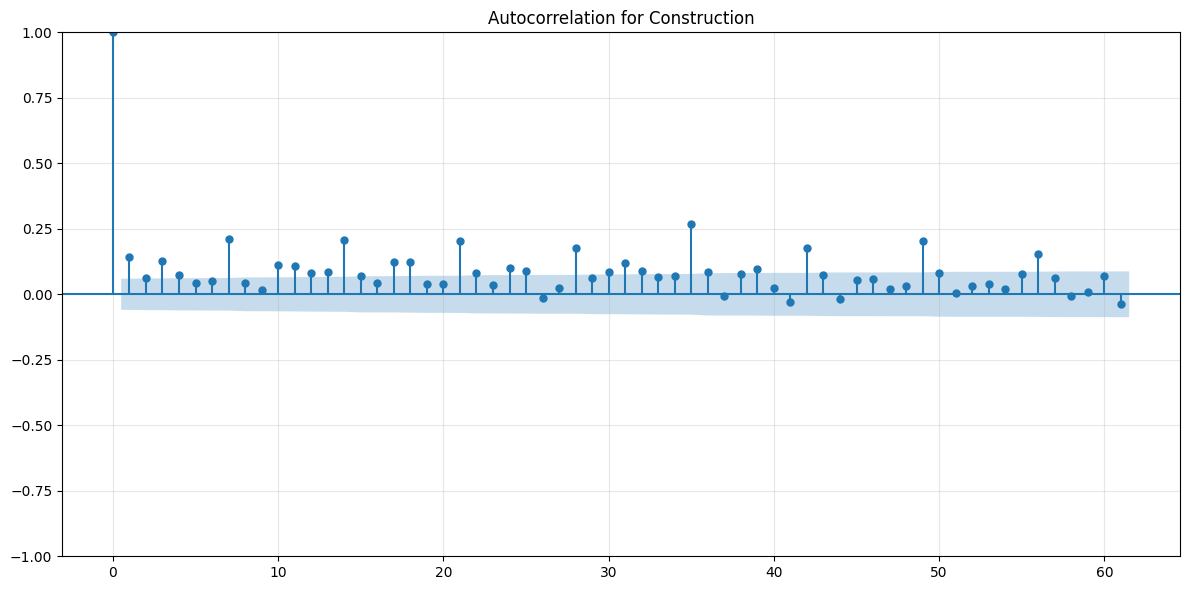

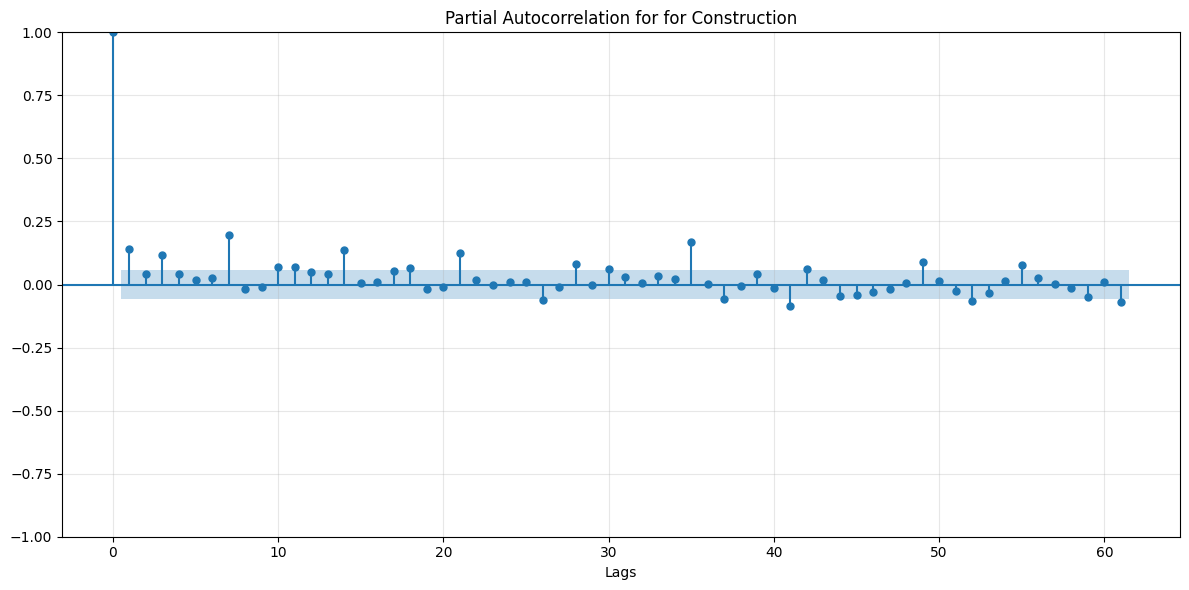

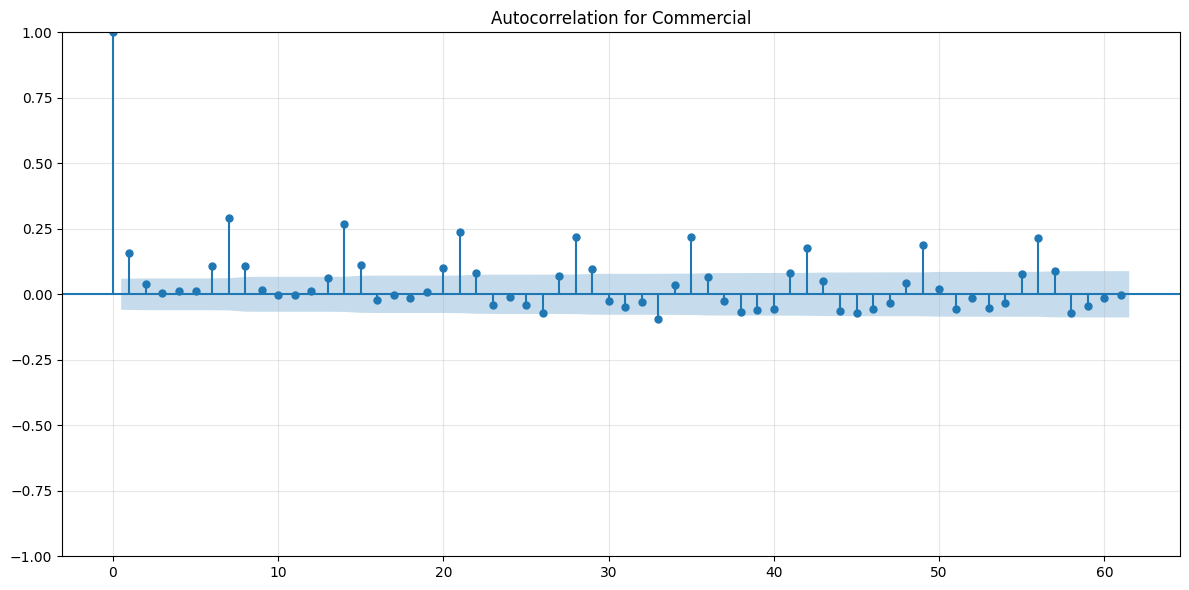

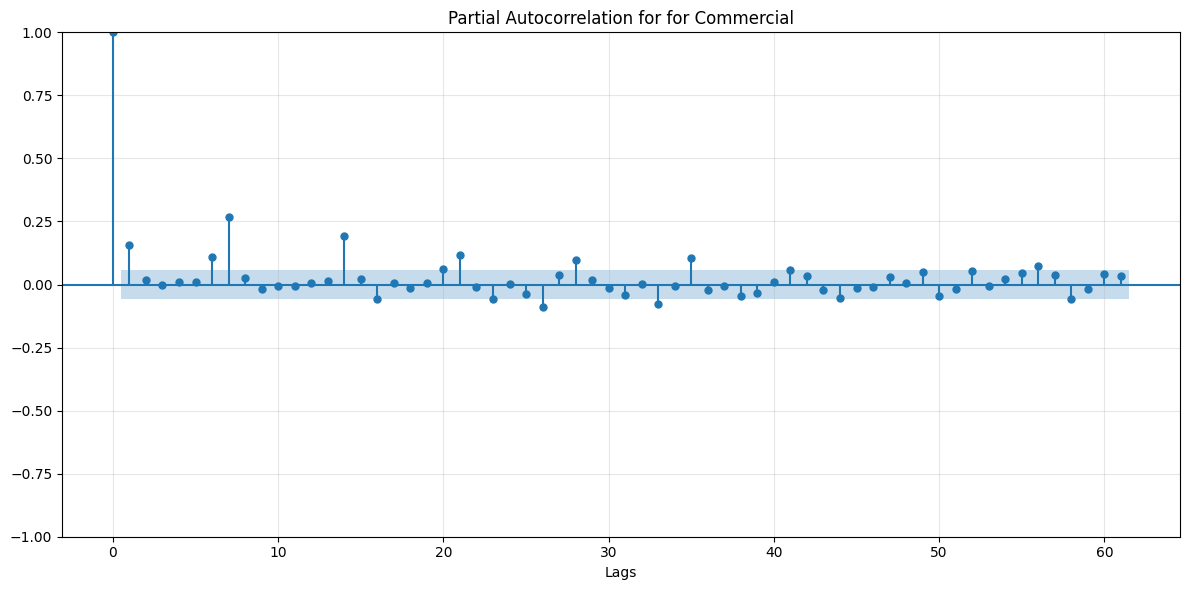

In [34]:
max_lag = 61

for waste in unique_waste:


    fig, ax = plt.subplots(figsize=(12, 6))
    plot_acf(waste_dfs[waste]["quantity_tons"], ax=ax, lags=max_lag)  
    plt.title(f'Autocorrelation for {waste}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))
    plot_pacf(waste_dfs[waste]["quantity_tons"], ax=ax, lags=max_lag)
    plt.title(f'Partial Autocorrelation for for {waste}')
    plt.xlabel("Lags")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Periodograms

High power frequencies for Municipal:
Frequency: 0.0027 cycles per day, Period: 365.33 days, Power: 5.74e+05
Frequency: 0.0137 cycles per day, Period: 73.07 days, Power: 1.32e+05
Frequency: 0.1423 cycles per day, Period: 7.03 days, Power: 4.08e+05
Frequency: 0.1432 cycles per day, Period: 6.98 days, Power: 6.24e+05
Frequency: 0.2856 cycles per day, Period: 3.50 days, Power: 5.62e+05
Frequency: 0.4288 cycles per day, Period: 2.33 days, Power: 1.01e+05
High power frequencies for Industrial:
Frequency: 0.4288 cycles per day, Period: 2.33 days, Power: 2.68e+05
High power frequencies for Organic:
Frequency: 0.0027 cycles per day, Period: 365.33 days, Power: 4.29e+05
High power frequencies for Construction:
Frequency: 0.0027 cycles per day, Period: 365.33 days, Power: 1.17e+05
High power frequencies for Commercial:
Frequency: 0.1432 cycles per day, Period: 6.98 days, Power: 1.02e+05
Frequency: 0.2856 cycles per day, Period: 3.50 days, Power: 1.02e+05


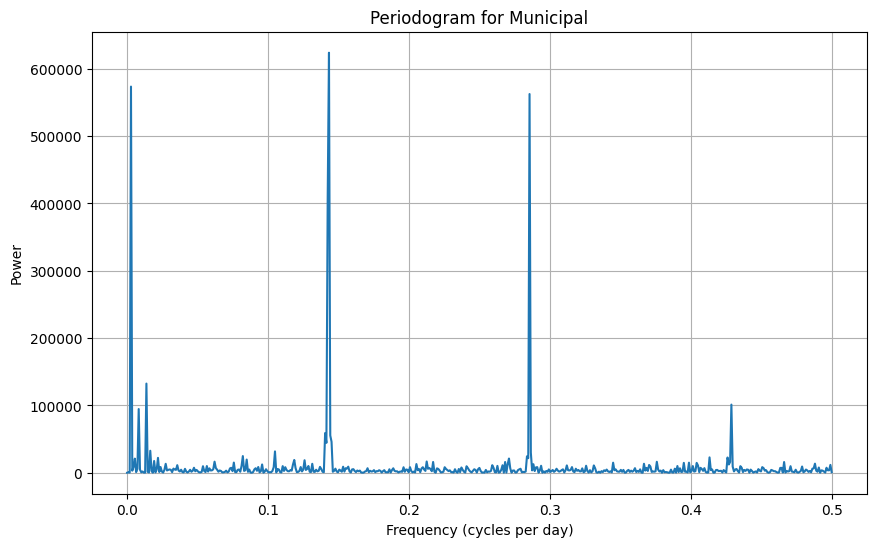

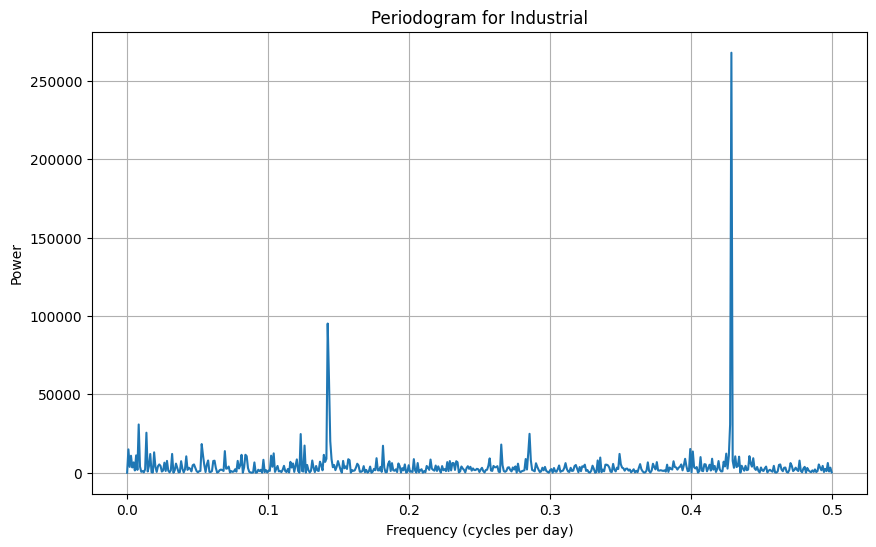

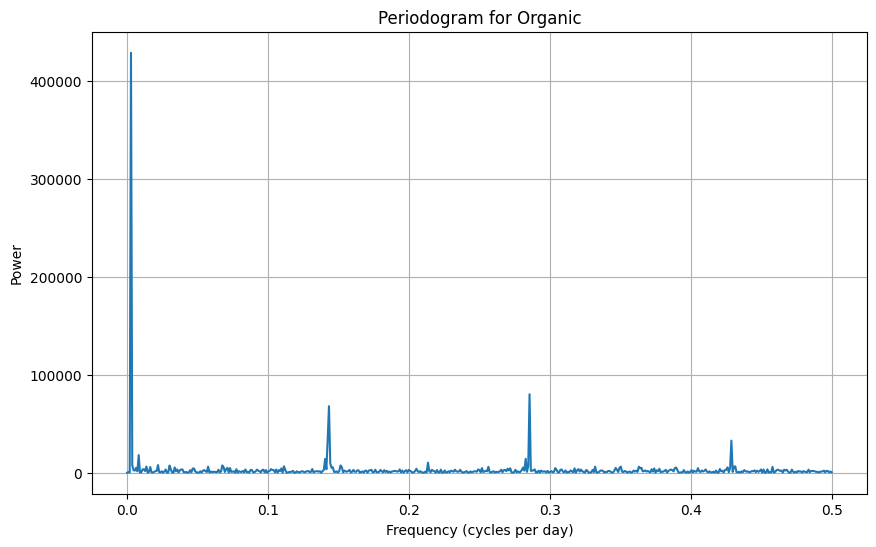

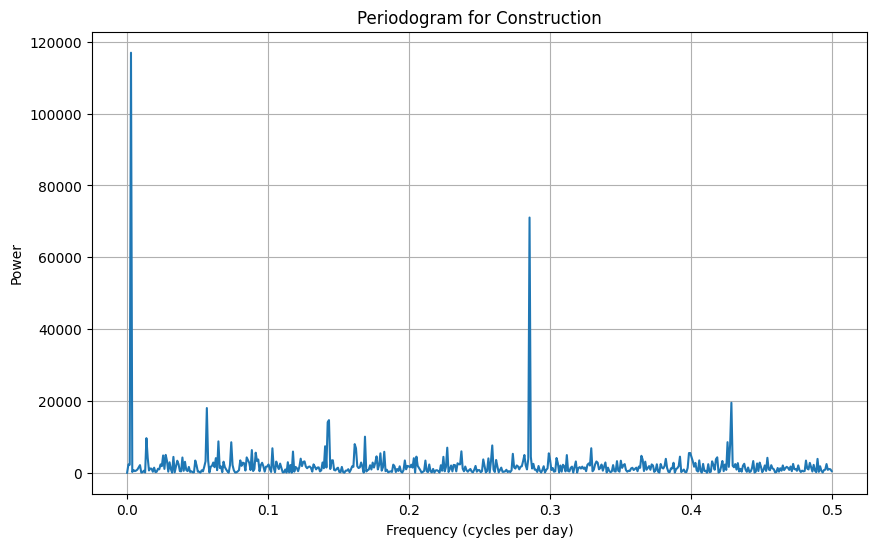

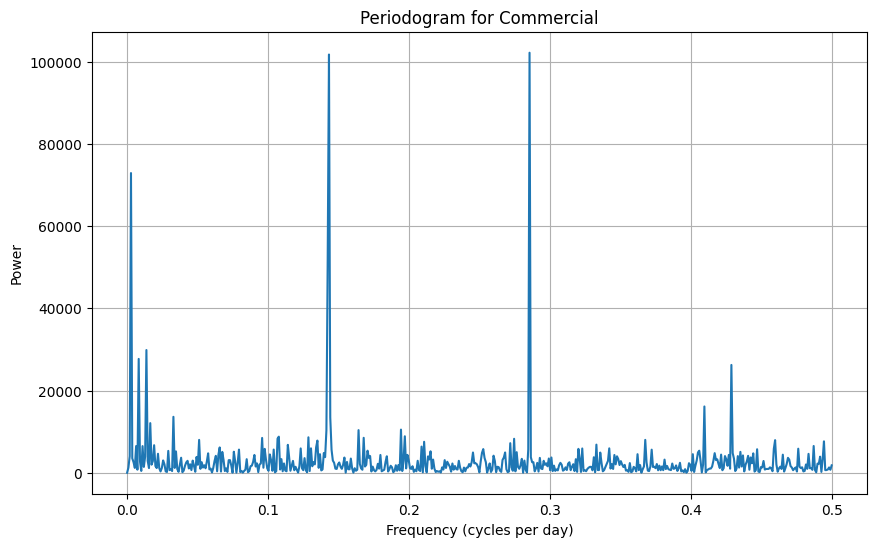

In [35]:

threshold = 1e5  # Adjust this threshold based on the power values in your periodograms

for waste in unique_waste:
    # Assuming 'quantity_tons' is your time series data
    data = waste_dfs[waste]['quantity_tons']

    fs = 1.0  # Sampling frequency (1 sample per day)
    freqs, power_spec = signal.periodogram(data, fs)

    # Find the indices where power exceeds the threshold
    high_power_indices = np.where(power_spec > threshold)[0]

    # Print the high power frequencies and their corresponding periods
    print(f"High power frequencies for {waste}:")
    for idx in high_power_indices:
        freq = freqs[idx]
        period = 1 / freq
        print(f"Frequency: {freq:.4f} cycles per day, Period: {period:.2f} days, Power: {power_spec[idx]:.2e}")

    plt.figure(figsize=(10, 6))
    plt.plot(freqs, power_spec)
    plt.xlabel('Frequency (cycles per day)')
    plt.ylabel('Power')
    plt.title(f'Periodogram for {waste}')
    plt.grid(True)
    